In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
stock_df = pd.read_csv("../data/raw/AAPL.csv")

stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [3]:
import os

os.listdir("../data/raw")

['AAPL.csv',
 'AMZN.csv',
 'GOOG.csv',
 'META.csv',
 'NVDA.csv',
 'raw_analyst_ratings.csv']

In [4]:
stock_df = pd.read_csv("../data/raw/AAPL.csv")

stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [5]:
stock_df.shape

(3774, 6)

In [6]:
stock_df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [7]:
stock_df.info()
stock_df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

The stock dataset contains historical daily trading information including opening price, closing price, adjusted closing price, and trading volume. These variables are essential for technical analysis and return calculations

In [8]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [9]:
stock_df = stock_df.sort_values(by='Date')

stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [10]:
stock_df.isnull().sum()
stock_df = stock_df.dropna()

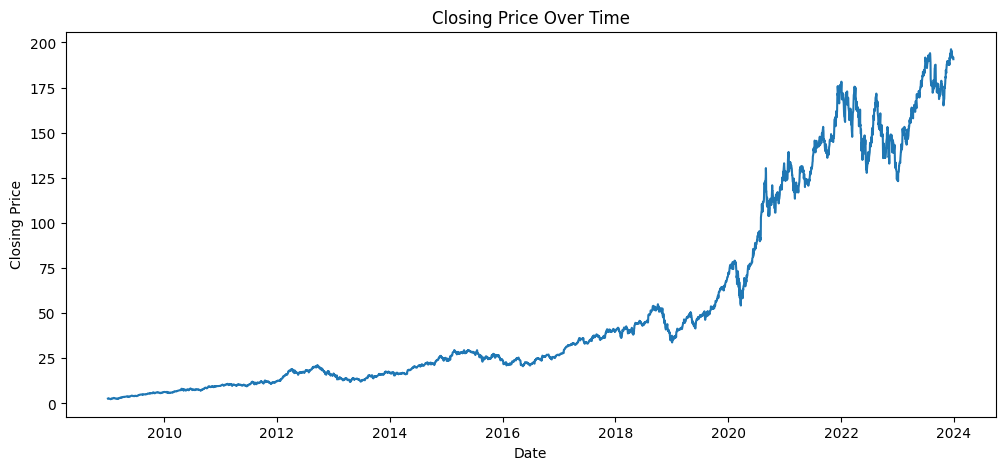

In [11]:
plt.figure(figsize=(12,5))

plt.plot(stock_df['Date'], stock_df['Close'])

plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

The closing price trend provides an overview of the stock’s historical market performance. Upward and downward trends may reflect changing investor sentiment, macroeconomic conditions, or company-specific events

In [12]:
stock_df.duplicated().sum()

np.int64(0)

Checking duplicate records is important in financial time-series analysis because duplicate trading days can distort technical indicators and return calculations

In [13]:
stock_df.describe()

,Date,Close,High,Low,Open,Volume
count,3774,3774.000000,3774.000000,3774.000000,3774.000000,3.774000e+03
mean,2016-07-01 03:40:32.432432,53.841169,54.383801,53.247465,53.801628,2.640640e+08
min,2009-01-02 00:00:00,2.345299,2.459265,2.345299,2.380989,2.404830e+07
25%,2012-09-28 18:00:00,15.050355,15.183043,14.901886,15.007580,9.581845e+07
50%,2016-06-30 12:00:00,26.975808,27.168844,26.836844,27.010205,1.667348e+08
75%,2020-03-31 18:00:00,74.664204,75.252383,73.553555,74.127927,3.777410e+08
max,2023-12-29 00:00:00,196.256592,197.752460,195.156944,196.167437,1.880998e+09
std,NaN,55.064042,55.627235,54.440128,55.009182,2.345629e+08


Descriptive statistics provide insight into the stock’s historical price distribution, volatility, and trading activity. Metrics such as mean, standard deviation, and volume help characterize market behavior

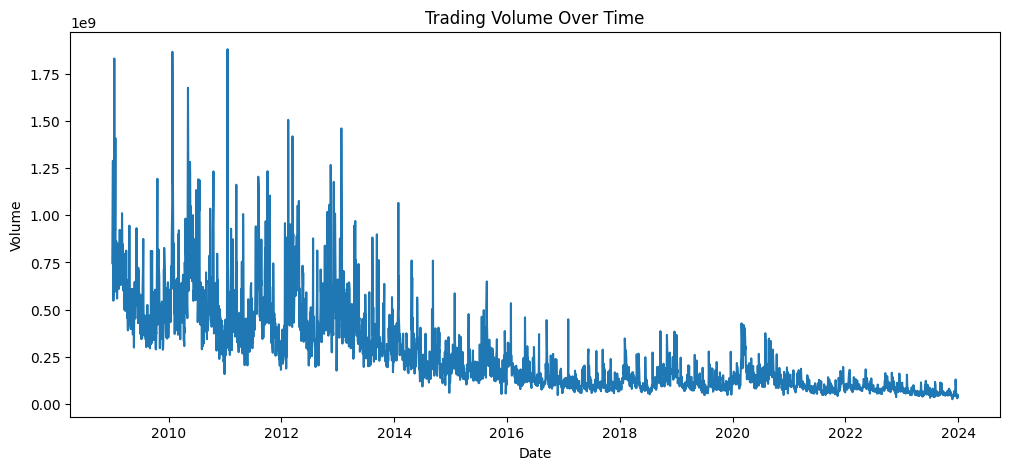

In [14]:
plt.figure(figsize=(12,5))

plt.plot(stock_df['Date'], stock_df['Volume'])

plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

Trading volume reflects market participation and liquidity. Sudden spikes in volume may indicate increased investor attention, institutional trading activity, or reactions to significant market events

In [15]:
stock_df['daily_change'] = stock_df['Close'].diff()

stock_df[['Date', 'daily_change']].head()

,Date,daily_change
0,2009-01-02,NaN
1,2009-01-05,0.114866
2,2009-01-06,-0.046786
3,2009-01-07,-0.060283
4,2009-01-08,0.050685


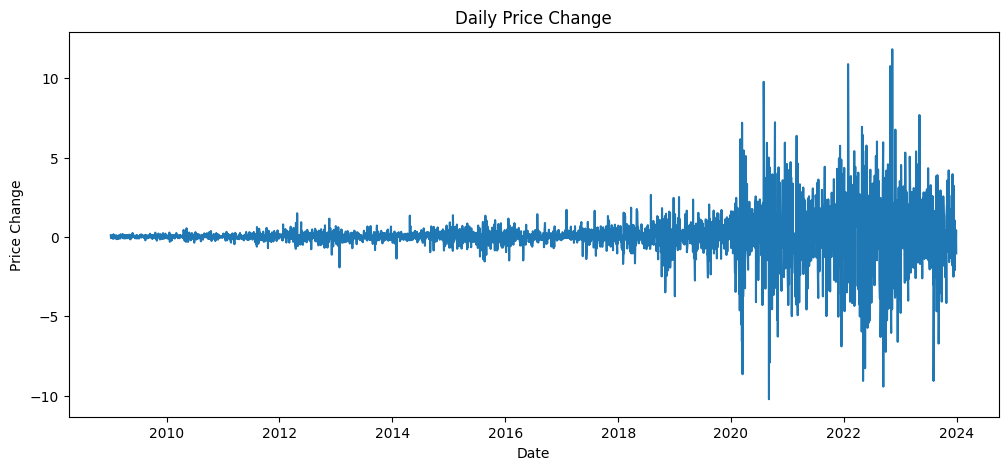

In [16]:
plt.figure(figsize=(12,5))

plt.plot(stock_df['Date'], stock_df['daily_change'])

plt.title("Daily Price Change")
plt.xlabel("Date")
plt.ylabel("Price Change")

plt.show()

Daily price changes help identify periods of high volatility and sudden market movements. Large fluctuations may correspond to earnings releases, macroeconomic events, or changes in investor sentiment.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
stock_df = pd.read_csv("../data/raw/AAPL.csv")

In [20]:
stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [21]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df = stock_df.sort_values('Date')
stock_df.set_index('Date', inplace=True)

In [22]:
stock_df['SMA_20'] = stock_df['Close'].rolling(window=20).mean()
stock_df['SMA_50'] = stock_df['Close'].rolling(window=50).mean()

In [23]:
stock_df['SMA_20'] = stock_df['Close'].rolling(20).mean()
stock_df['SMA_50'] = stock_df['Close'].rolling(50).mean()
stock_df['EMA_20'] = stock_df['Close'].ewm(span=20).mean()

In [24]:
delta = stock_df['Close'].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
stock_df['RSI'] = 100 - (100 / (1 + rs))

In [25]:
ema_12 = stock_df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = stock_df['Close'].ewm(span=26, adjust=False).mean()

stock_df['MACD'] = ema_12 - ema_26
stock_df['Signal'] = stock_df['MACD'].ewm(span=9, adjust=False).mean()
stock_df['MACD_Hist'] = stock_df['MACD'] - stock_df['Signal']

In [26]:
print(stock_df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'EMA_20',
       'RSI', 'MACD', 'Signal', 'MACD_Hist'],
      dtype='str')


In [27]:
stock_df['SMA_20'] = stock_df['Close'].rolling(window=20).mean()
stock_df['SMA_50'] = stock_df['Close'].rolling(window=50).mean()

In [28]:
print(stock_df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'EMA_20',
       'RSI', 'MACD', 'Signal', 'MACD_Hist'],
      dtype='str')


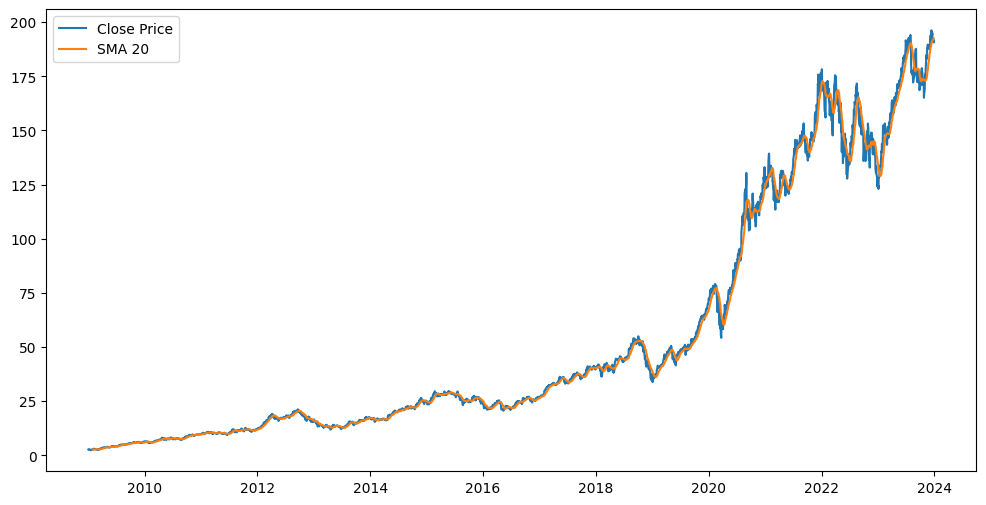

In [29]:
plt.figure(figsize=(12,6))
plt.plot(stock_df['Close'], label='Close Price')
plt.plot(stock_df['SMA_20'], label='SMA 20')
plt.legend()
plt.show()

In [30]:
stock_df = stock_df.dropna().reset_index(drop=True)
stock_df.head()

,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI,MACD,Signal,MACD_Hist
0,2.861745,2.920827,2.824556,2.895035,797244000,2.716199,2.733174,2.745575,58.665726,0.010822,-0.013715,0.024537
1,2.988908,2.989807,2.851248,2.856347,786646000,2.723891,2.738518,2.768891,62.816649,0.028693,-0.005233,0.033927
2,3.044690,3.103472,2.990706,2.996404,796037200,2.734613,2.742681,2.795303,68.653496,0.046817,0.005177,0.041641
3,3.047690,3.095075,3.006602,3.054588,500180800,2.751078,2.747839,2.819460,68.634544,0.060723,0.016286,0.044437
4,3.046790,3.092377,3.016200,3.061785,695587200,2.766659,2.754185,2.841208,71.536788,0.070854,0.027200,0.043655


In [31]:
print(stock_df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'EMA_20',
       'RSI', 'MACD', 'Signal', 'MACD_Hist'],
      dtype='str')


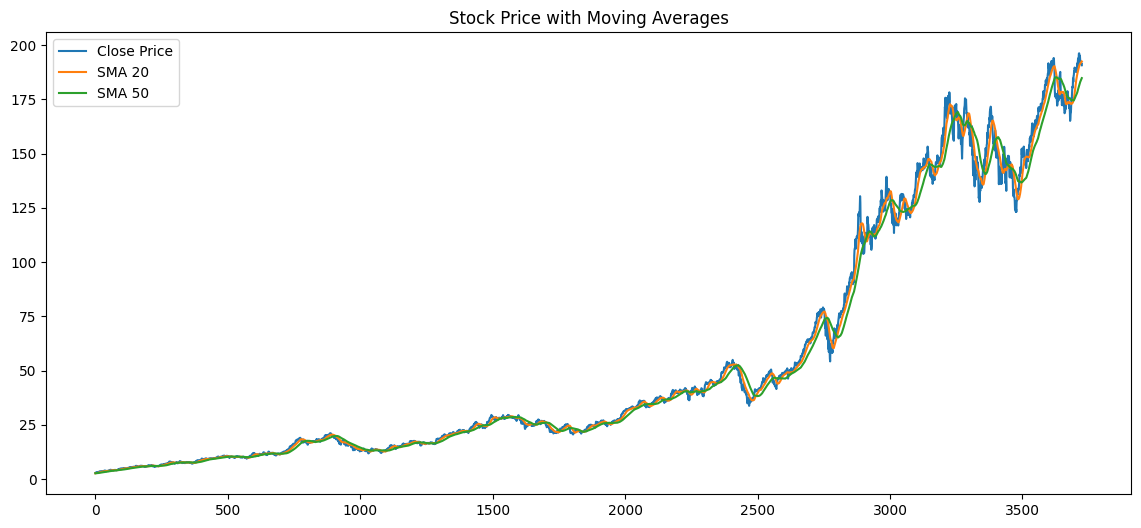

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(stock_df['Close'], label='Close Price')
plt.plot(stock_df['SMA_20'], label='SMA 20')
plt.plot(stock_df['SMA_50'], label='SMA 50')
plt.title("Stock Price with Moving Averages")
plt.legend()
plt.show()

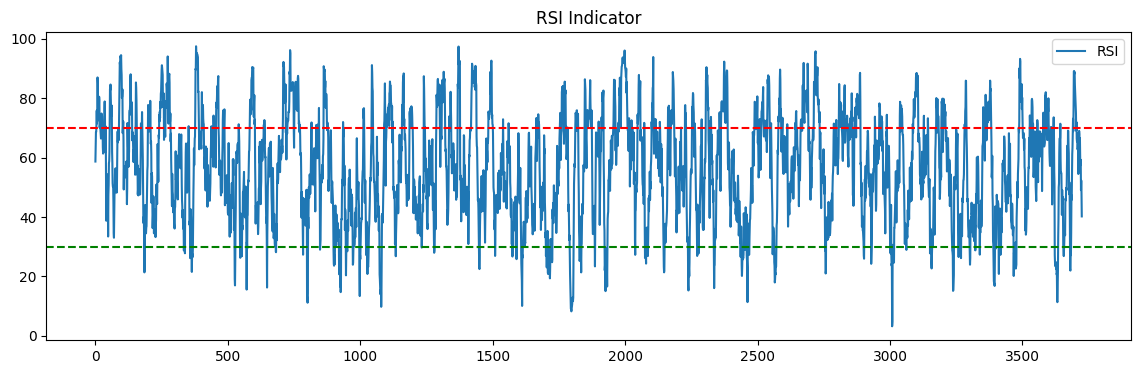

In [33]:
plt.figure(figsize=(14,4))
plt.plot(stock_df['RSI'], label='RSI')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title("RSI Indicator")
plt.legend()
plt.show()

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
import os

print(os.listdir("../data/raw"))

['AAPL.csv', 'AMZN.csv', 'GOOG.csv', 'META.csv', 'NVDA.csv', 'raw_analyst_ratings.csv']


In [36]:
stock_df = pd.read_csv("../data/raw/AAPL.csv")

In [37]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

In [38]:
import pandas as pd
import numpy as np

stock_df = pd.read_csv("../data/raw/AAPL.csv")

stock_df['Date'] = pd.to_datetime(stock_df['Date'])

stock_df['SMA_20'] = stock_df['Close'].rolling(20).mean()
stock_df['SMA_50'] = stock_df['Close'].rolling(50).mean()

stock_df['EMA_12'] = stock_df['Close'].ewm(span=12, adjust=False).mean()
stock_df['EMA_26'] = stock_df['Close'].ewm(span=26, adjust=False).mean()

stock_df['MACD'] = stock_df['EMA_12'] - stock_df['EMA_26']
stock_df['Signal'] = stock_df['MACD'].ewm(span=9, adjust=False).mean()
stock_df['MACD_Hist'] = stock_df['MACD'] - stock_df['Signal']

stock_df['volatility'] = stock_df['Close'].pct_change().rolling(20).std()

stock_df.dropna(inplace=True)

stock_df.head()

,Date,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_12,EMA_26,MACD,Signal,MACD_Hist,volatility
49,2009-03-16,2.861745,2.920827,2.824556,2.895035,797244000,2.716199,2.733174,2.754833,2.744011,0.010822,-0.013715,0.024537,0.032609
50,2009-03-17,2.988908,2.989807,2.851248,2.856347,786646000,2.723891,2.738518,2.790844,2.762151,0.028693,-0.005233,0.033927,0.032315
51,2009-03-18,3.044690,3.103472,2.990706,2.996404,796037200,2.734613,2.742681,2.829898,2.783080,0.046817,0.005177,0.041641,0.032475
52,2009-03-19,3.047690,3.095075,3.006602,3.054588,500180800,2.751078,2.747839,2.863404,2.802681,0.060723,0.016286,0.044437,0.030829
53,2009-03-20,3.046790,3.092377,3.016200,3.061785,695587200,2.766659,2.754185,2.891617,2.820763,0.070854,0.027200,0.043655,0.030863


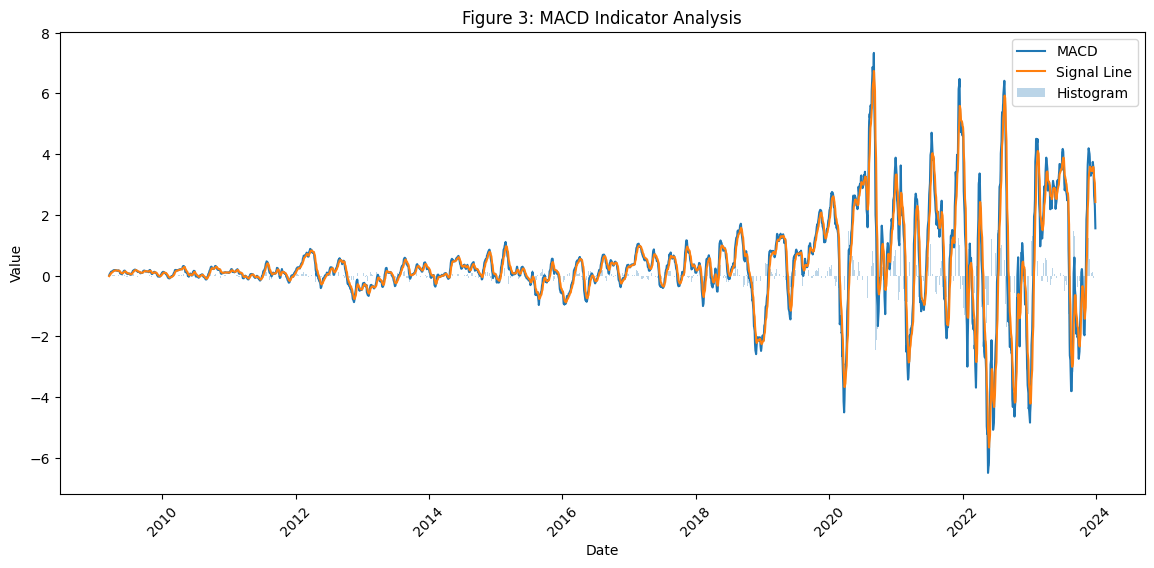

In [39]:
plt.figure(figsize=(14,6))

plt.plot(stock_df['Date'], stock_df['MACD'], label='MACD')
plt.plot(stock_df['Date'], stock_df['Signal'], label='Signal Line')

plt.bar(stock_df['Date'], stock_df['MACD_Hist'], label='Histogram', alpha=0.3)

plt.title("Figure 3: MACD Indicator Analysis")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.xticks(rotation=45)

plt.show()

In [40]:
stock_df['volatility'] = stock_df['Close'].pct_change().rolling(20).std()

In [41]:
# Make sure data is sorted
stock_df = stock_df.sort_values('Date')

# Calculate EMAs
stock_df['EMA_12'] = stock_df['Close'].ewm(span=12, adjust=False).mean()
stock_df['EMA_26'] = stock_df['Close'].ewm(span=26, adjust=False).mean()

# MACD line
stock_df['MACD'] = stock_df['EMA_12'] - stock_df['EMA_26']

# Signal line
stock_df['Signal'] = stock_df['MACD'].ewm(span=9, adjust=False).mean()

# Histogram
stock_df['MACD_Hist'] = stock_df['MACD'] - stock_df['Signal']

In [42]:
print(stock_df[['MACD', 'Signal', 'MACD_Hist']].head())

        MACD    Signal  MACD_Hist
49  0.000000  0.000000   0.000000
50  0.010144  0.002029   0.008115
51  0.022426  0.006108   0.016318
52  0.032032  0.011293   0.020739
53  0.039122  0.016859   0.022263


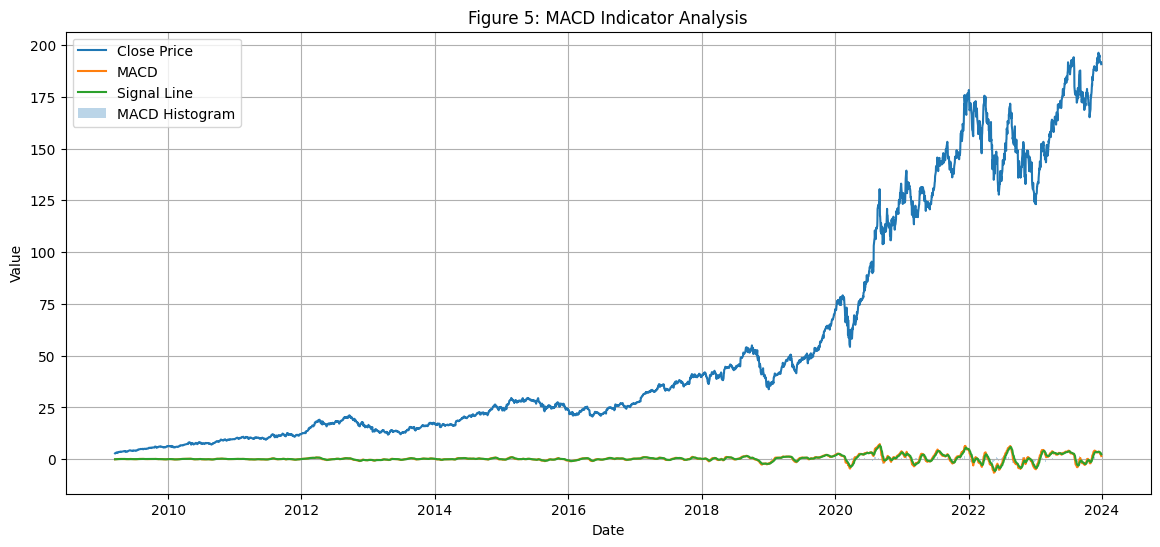

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(stock_df['Date'], stock_df['Close'], label='Close Price')
plt.plot(stock_df['Date'], stock_df['MACD'], label='MACD')
plt.plot(stock_df['Date'], stock_df['Signal'], label='Signal Line')

plt.bar(stock_df['Date'], stock_df['MACD_Hist'], alpha=0.3, label='MACD Histogram')

plt.title("Figure 5: MACD Indicator Analysis")
plt.xlabel("Date")
plt.ylabel("Value")

plt.legend()
plt.grid(True)

plt.savefig("figure5_macd.png", dpi=300, bbox_inches='tight')

plt.show()

## Task 2 Summary

In this task, historical stock price data was analyzed using technical indicators to understand market behavior.

### Key Steps:
- Loaded and cleaned stock price dataset
- Handled missing values and ensured correct data types
- Computed technical indicators:
  - Simple Moving Average (SMA 20, 50)
  - Exponential Moving Average (EMA 20, 50)
  - Relative Strength Index (RSI)
  - MACD and Signal Line
- Calculated daily percentage returns
- Visualized price trends and momentum indicators

### Insights:
- Moving averages helped identify trend direction
- RSI highlighted overbought/oversold conditions
- MACD captured momentum shifts and trend reversals

### Limitation:
- Indicators are lagging and do not guarantee prediction accuracy
- External market news is not included (will be used in Task 3)

In [44]:
stock_df[['daily_change', 'RSI', 'MACD']].corr()

KeyError: "['daily_change', 'RSI'] not in index"